In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from helpers.glitch_shapes import *
from helpers.gw_shapes import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, Glitch, IntegratedShapeletGlitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore")

In [2]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

In [120]:
glitch_param_path = DIST / 'glitch_params_ordinary.txt'
data = np.loadtxt(glitch_param_path, skiprows=1)

betas = data[:, 0]
levels = data[:, 1]
snrs = data[:, 2]

levels = levels[betas < 500]
betas = betas[betas < 500]

In [15]:
#real_glitch_path = str(DIST / 'real_glitch_output.h5')
pipe = {'t0':10368000, 'dt':0.25, 'size':10*3600/0.25}

#glitches = [{'type':'ShapeletGlitch', 't_inj': 5*3600, 'beta':betas[2],
 #            'level':1e4*levels[2], 'inj_point':'tm_12'}]
glitches = [{'type':'OneSidedDoubleExpGlitch', 't_inj': 0,
             'level':0, 't_rise':1, 't_fall':1, 'inj_point':'tm_23'}]
#glitches = [{'type':'RealGlitch', 't_inj': 5*3600, 'scale':1e5,
 #            'run':3, 'index':2, 'inj_point':'tm_23'}]
#glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': 5*3600, 'beta':8.6e-1,
 #            'level':2*2.3e-13*8.6e-1, 'inj_point':'tm_12'}]

#gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1,
 #       'gw_beta':0.02*np.pi, 'gw_lambda':0.98*np.pi}]
gws = [{'type': 'BinaryInspiralGW', 'm1': 1e5, 'm2': 1e5, 'd': 1e4,
        'spin1': 0.42, 'spin2': -0.42, 't_inj': 5.9*3600, 'domain': 'freq', 'gw_beta':0.09*np.pi, 'gw_lambda':1.09*np.pi}]

In [16]:
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False)
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using a glitch file in a version that might not be fully supported


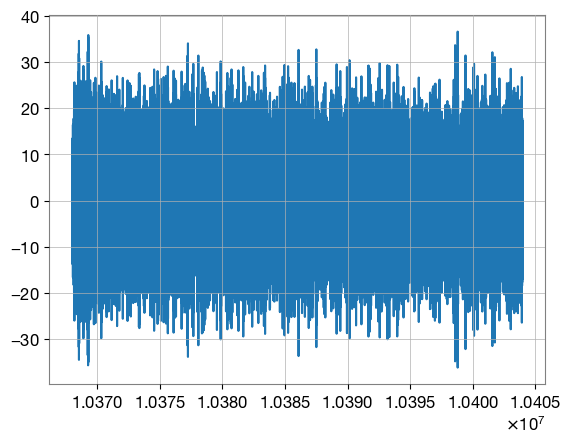

In [8]:
plt.plot(raw_dict['X'])

In [3]:
gw = gws[0]
gw = BinaryInspiralGW(m1=gw['m1'], m2=gw['m2'], d=gw['d'], t_inj=gw['t_inj'],
                 spin1=gw['spin1'], spin2=gw['spin2'], domain='freq',
                 gw_lambda=gw['gw_lambda'], gw_beta=gw['gw_beta'], orbits=orbits_path)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported


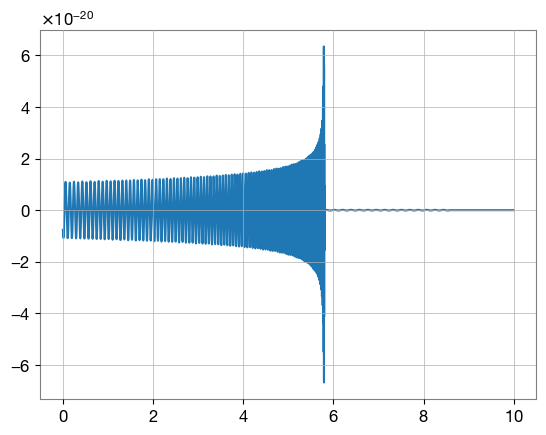

In [4]:
t = np.arange(0, 10*3600, 0.25)
h = np.sqrt(gw.hp**2 + gw.hc**2)
#y = gw.compute_signal(h=h, amp = gw.amp_hp, t=t)
y = gw.compute_hplus(t)

plt.plot(t/3600, y)

In [21]:
inst = Instrument(size=pipe['size'], dt=pipe['dt'], t0=pipe['t0'],
        orbits=orbits_path, physics_upsampling=1, aafilter=None,
        glitches=glitch_path, gws=gw_path)

You are using a glitch file in a version that might not be fully supported


In [9]:
specs = {'low_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':10,
                       'drange':np.logspace(4, 5, 5)}}

In [17]:
event = gws[0]
channel = 'X'
res = 256
spec = specs['high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
#t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
 #                            frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

0.5628669261932373


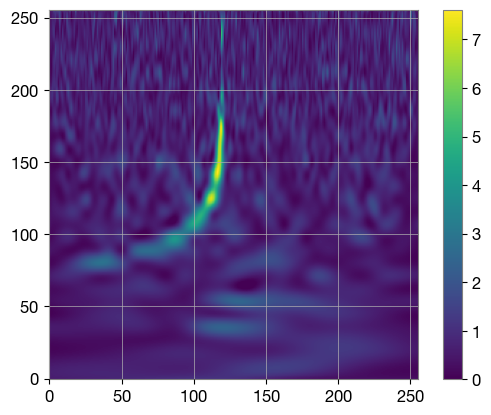

In [18]:
plt.imshow(QT, origin='lower')
#plt.clim(0, 90)
plt.colorbar()
plt.show()

## SNR calculation

In [35]:
def lisa_noise_psd(f):
    
    c = 299792458
    L = 2.5e9
    
    N_TM = 2.4e-15      # m/s^2 / sqrt(Hz)
    N_OMS = 7.9e-12     # m / sqrt(Hz)
    
    # acceleration noise PSD
    S_TM = (N_TM**2) * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4)
    
    # OMS displacement noise PSD
    S_OMS = (N_OMS**2) * (1 + (2.0e-3 / f)**4)
    
    # conversion factors
    C_acc = (1 / (c * 2*np.pi * f))**2
    C_disp = (2*np.pi * f / c)**2
    
    # useful trig
    x = 2*np.pi * L * f / c
    
    sinx = np.sin(x)
    cosx = np.cos(x)
    
    sin2 = sinx**2
    
    # A and E channels (identical)
    SA = 8*sin2 * (
        2*C_acc*S_TM*(3 + 2*cosx + np.cos(2*x))
        + C_disp*S_OMS*(2 + cosx)
    )
    
    SE = SA.copy()
    
    # T channel
    ST = (
        16*C_disp*S_OMS*(1 - cosx)*sin2
        + 128*C_acc*S_TM*sin2*(np.sin(x/2)**4)
    )
    
    return SA, SE, ST

In [40]:
T_obs = 10*3600
del_f = 1/T_obs
L = 2.5e9/3e8
f = np.arange(1e-4, 1e-1, del_f)

TX = np.exp(-16*1j*L*np.pi*f)*(-1 + np.exp(8*1j*L*np.pi*f))**2
TY = 8*np.exp(-8*1j*L*np.pi*f)*np.sin(4*L*np.pi*f)*np.sin(2*L*np.pi*f)
TZ = 0

TA = (TZ - TX)/np.sqrt(2)
TE = (TX - 2*TY + TZ)/np.sqrt(6)
TT = (TX + TY + TZ)/np.sqrt(3)

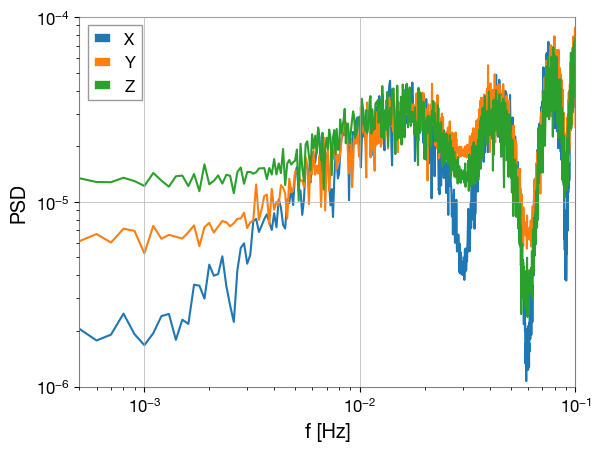

In [53]:
SX_sim = np.load(PSD_PATH / 'psd_X.npz')
SY_sim = np.load(PSD_PATH / 'psd_Y.npz')
SZ_sim = np.load(PSD_PATH / 'psd_Z.npz')

plt.loglog(SX_sim['f_psd'], np.sqrt(SX_sim['psd']), label='X')
plt.loglog(SY_sim['f_psd'], np.sqrt(SY_sim['psd']), label='Y')
plt.loglog(SZ_sim['f_psd'], np.sqrt(SZ_sim['psd']), label='Z')

plt.xlabel('f [Hz]')
plt.ylabel('PSD')
plt.xlim(5e-4, 1e-1)
plt.ylim(1e-6, 1e-4)
plt.legend()
plt.show()

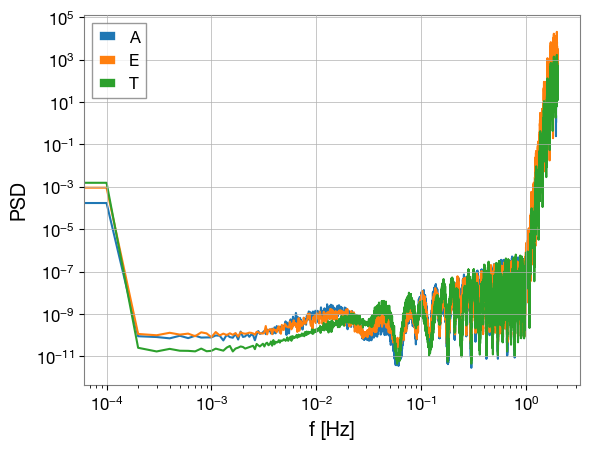

In [42]:
SA_sim = np.load(PSD_PATH / 'psd_A.npz')
SE_sim = np.load(PSD_PATH / 'psd_E.npz')
ST_sim = np.load(PSD_PATH / 'psd_T.npz')

plt.loglog(SA_sim['f_psd'], SA_sim['psd'], label='A')
plt.loglog(SE_sim['f_psd'], SE_sim['psd'], label='E')
plt.loglog(ST_sim['f_psd'], ST_sim['psd'], label='T')

plt.xlabel('f [Hz]')
plt.ylabel('PSD')
plt.legend()
plt.show()

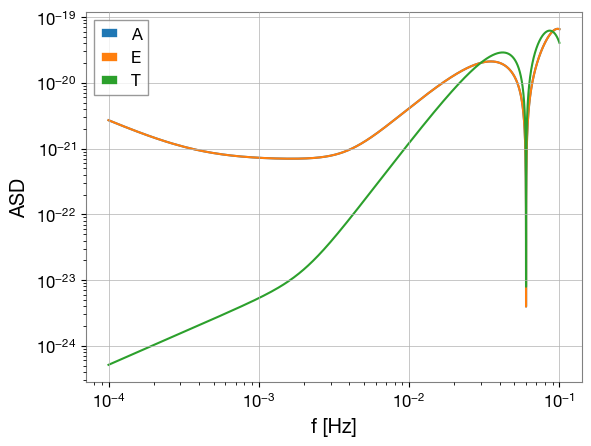

In [44]:
SA, SE, ST = lisa_noise_psd(f)

plt.loglog(f, np.sqrt(SA), label='A')
plt.loglog(f, np.sqrt(SE), label='E')
plt.loglog(f, np.sqrt(ST), label='T')

plt.xlabel('f [Hz]')
plt.ylabel('ASD')
plt.legend()
plt.show()

In [54]:
help(Instrument)

Help on class Instrument in module lisainstrument.instrument:

class Instrument(builtins.object)
 |  Instrument(size=2592000, dt=0.25, t0='orbits', physics_upsampling=4, aafilter=('kaiser', 240, 1.1, 2.9), telemetry_downsampling=345600, initial_telemetry_size=0, orbits='static', orbit_dataset='tps/ppr', gws=None, interpolation=('lagrange', 31), glitches=None, lock='N1-12', fplan='static', laser_asds=30, laser_shape='white+infrared', central_freq=281600000000000.0, offset_freqs='default', modulation_asds='default', modulation_freqs='default', tdir_modulations=None, clock_asds=6.32e-14, clock_offsets=0, clock_freqoffsets='default', clock_freqlindrifts='default', clock_freqquaddrifts='default', clockinv_tolerance=1e-10, clockinv_maxiter=5, backlink_asds=3e-12, backlink_fknees=0.002, testmass_asds=2.4e-15, testmass_fknees=0.0004, oms_asds=(6.35e-12, 1.25e-11, 1.42e-12, 3.38e-12, 3.32e-12, 7.9e-12), oms_fknees=0.002, moc_time_correlation_asds=0.42, ttl_coeffs='default', sc_jitter_asds=(5e-0